# R-Peak Detection for ECGRDVQ Dataset

1. DataLoader: Handles PhysioNet file reading and resampling.
2. PreProcessor: Handles Wavelet denoising and your new Polarity Correction module.
3. FeatureExtractor: Computes the Absolute Slope (or other features like Energy).
4. PeakDetector: Runs the Segmented K-Means.
5. Evaluator: Compares detections against .atr files and generates the $Se/PPV$ tables.

['Ranolazine' 'Verapamil HCL' 'Placebo' 'Quinidine Sulph' 'Dofetilide']
Loaded record 49649923-6d81-42a6-abcb-57c2a8095c6d (Drug: Dofetilide, Subject: 1001), fs = 1000.0 Hz, N = 10000 samples
Detected 11 peaks for Dofetilide, record 49649923-6d81-42a6-abcb-57c2a8095c6d


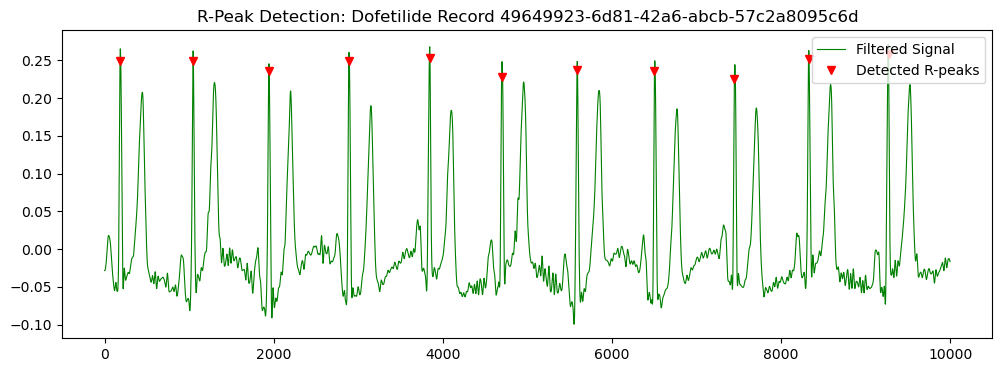

In [63]:
import pandas as pd
import wfdb
import numpy as np
import pywt
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

class RPeakDetector:
    def __init__(self, fs=1000):
        self.fs = fs

    def detect(self, ecg):
        # --- 1. Wavelet Denoising ---
        wavelet = 'sym8'
        level = 9
        coeffs = pywt.wavedec(ecg, wavelet, level=level)
        
        # Keep cD9 through cD5 (Indices 1 to 5)
        keep_levels = [1, 2, 3, 4, 5]
        clean_coeffs = [np.zeros_like(c) for c in coeffs]
        for k in keep_levels:
            clean_coeffs[k] = coeffs[k]
        
        clean_signal = pywt.waverec(clean_coeffs, wavelet)[:len(ecg)]

        # --- 2. Polarity Detection ---
        # Use first 10 seconds to check if signal should be flipped
        ref = clean_signal[:int(10 * self.fs)]
        polarity = 1 if np.max(ref) >= np.abs(np.min(ref)) else -1
        clean_signal = clean_signal * polarity

        # --- 3. Segmented K-Means (QRS Mask) ---
        abs_slope = np.abs(np.gradient(clean_signal))
        segment_len = int(60 * self.fs)
        qrs_mask = np.zeros(len(abs_slope), dtype=bool)
        
        for start in range(0, len(abs_slope), segment_len):
            end = min(start + segment_len, len(abs_slope))
            segment = abs_slope[start:end].reshape(-1, 1)
            
            kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
            labels = kmeans.fit_predict(segment)
            
            # QRS cluster is the one with the higher centroid
            qrs_cluster = np.argmax(kmeans.cluster_centers_.flatten())
            qrs_mask[start:end] = (labels == qrs_cluster)

        # --- 4. Region Extraction & Peak Detection ---
        max_samples = int(250 / 1000 * self.fs) # 250ms max QRS duration
        r_peaks_raw = []
        in_region = False
        start_idx = 0
        
        for i, val in enumerate(qrs_mask):
            if val and not in_region:
                start_idx, in_region = i, True
            elif not val and in_region:
                duration = i - start_idx
                if duration <= max_samples:
                    # Find max amplitude in this region
                    peak_idx = start_idx + np.argmax(clean_signal[start_idx:i])
                    r_peaks_raw.append(peak_idx)
                in_region = False

        # --- 5. Refractory Filter ---
        if not r_peaks_raw:
            return clean_signal, np.array([])
            
        refractory_samples = int(200 / 1000 * self.fs) # 200ms refractory period
        r_peaks = [r_peaks_raw[0]]
        
        for peak in r_peaks_raw[1:]:
            if peak - r_peaks[-1] >= refractory_samples:
                r_peaks.append(peak)
            else:
                # If too close, keep the one with higher amplitude
                if clean_signal[peak] > clean_signal[r_peaks[-1]]:
                    r_peaks[-1] = peak

        return clean_signal, np.array(r_peaks)

# --- THE DATA LOADER ---
def load_ecgrdvq_record(drug_name="Ranolazine"):
    csv_url = "https://physionet.org/files/ecgrdvq/1.0.0/SCR-002.Clinical.Data.csv"
    clinical_df = pd.read_csv(csv_url)

    # Check available drugs
    available_drugs = clinical_df["EXTRT"].unique()
    print(available_drugs)

    record_row = clinical_df[clinical_df["EXTRT"] == drug_name].iloc[0]

    subject_id = str(int(record_row["RANDID"]))
    record_id = record_row["EGREFID"]
    pn_dir = f"ecgrdvq/1.0.0/raw/{subject_id}/"
    
    record = wfdb.rdrecord(record_id, pn_dir=pn_dir)
    # Use the first ECG channel by default
    ecg = record.p_signal[:, 0].astype(float)
    fs = float(record.fs)

    info = {
        "drug": drug_name,
        "subject_id": subject_id,
        "record_id": record_id,
    }

    print(
        f"Loaded record {record_id} "
        f"(Drug: {drug_name}, Subject: {subject_id}), "
        f"fs = {fs} Hz, N = {len(ecg)} samples"
    )

    return ecg, float(record.fs), record_id

# --- EXECUTION ---
drug = "Dofetilide"
ecg_sig, fs, rec_id = load_ecgrdvq_record(drug)
detector = RPeakDetector(fs=fs)
clean_sig, peaks = detector.detect(ecg_sig)

print(f"Detected {len(peaks)} peaks for {drug}, record {rec_id}")

# Visualization
plt.figure(figsize=(12, 4))
plt.plot(clean_sig[:10000], 'green', linewidth=0.8)
plt.plot(peaks[peaks < 10000], clean_sig[peaks[peaks < 10000]], 'rv', label="Detected R-peaks")
plt.title(f"R-Peak Detection: {drug} Record {rec_id}")
plt.legend()
plt.show()

## Testing in different records and drugs

In [66]:
import pandas as pd
import wfdb
import numpy as np
from tqdm import tqdm
import neurokit2 as nk
import warnings

warnings.filterwarnings("ignore")

# 1. Load the clinical data
csv_url = "https://physionet.org/files/ecgrdvq/1.0.0/SCR-002.Clinical.Data.csv"
clinical_df = pd.read_csv(csv_url)

# 2. Create a Stratified Subset (Max 5 records per drug category)
stratified_df = clinical_df.groupby("EXTRT").head(5).reset_index(drop=True)
print(f"Testing on {len(stratified_df)} records...")

# 3. Setup
results = []
detector = RPeakDetector(fs=1000)

for index, row in tqdm(stratified_df.iterrows(), total=len(stratified_df)):
    try:
        subject_id = str(int(row["RANDID"]))
        record_id = row["EGREFID"]
        drug = row["EXTRT"]
        pn_dir = f"ecgrdvq/1.0.0/raw/{subject_id}/"
        
        # Stream the record
        record = wfdb.rdrecord(record_id, pn_dir=pn_dir)
        ecg_sig = record.p_signal[:, 0].astype(float)
        fs = float(record.fs)
        duration_sec = len(ecg_sig) / fs
        
        # --- METHOD A: Your Proposed Wavelet + K-Means Pipeline ---
        clean_sig, proposed_peaks = detector.detect(ecg_sig)
        proposed_bpm = (len(proposed_peaks) / duration_sec) * 60
        
        # --- METHOD B: Pan-Tompkins Baseline (via NeuroKit2) ---
        _, info = nk.ecg_peaks(ecg_sig, sampling_rate=fs, method="pantompkins1985")
        pt_peaks = info["ECG_R_Peaks"]
        pt_bpm = (len(pt_peaks) / duration_sec) * 60
        
        # Calculate Absolute Error
        abs_error = abs(proposed_bpm - pt_bpm)
        
        # Store results
        results.append({
            "Record": record_id,
            "Drug": drug,
            "Proposed_BPM": proposed_bpm,
            "PT_BPM": pt_bpm,
            "Error_BPM": abs_error,
            "PT_Peaks": pt_peaks
        })
            
    except Exception as e:
        print(f"Failed processing {record_id}: {e}")

Testing on 25 records...


100%|██████████| 25/25 [00:41<00:00,  1.65s/it]


In [67]:
results_df = pd.DataFrame(results)

if len(results_df) > 0:    
    mae = results_df['Error_BPM'].mean()
    print(f"\nMean Absolute Error (vs Pan-Tompkins): {mae:.2f} BPM")
    
    # Show the first 5 records as an example for your LaTeX table
    print("\nSample Results:")
    print(results_df[['Drug', 'Record', 'Proposed_BPM', 'PT_BPM', 'Error_BPM']].head(25).round(2))
else:
    print("No results generated.")


Mean Absolute Error (vs Pan-Tompkins): 59.76 BPM

Sample Results:
               Drug                                Record  Proposed_BPM  \
0        Ranolazine  491af4aa-941a-4a89-b74c-b38d91cfc5e9          66.0   
1        Ranolazine  db4d09aa-f26c-4acb-92fd-6ac316918bc8          66.0   
2        Ranolazine  dd3caf18-354d-4c81-9ff5-6aed843cd84b          72.0   
3        Ranolazine  12133f6e-efcf-48cc-a184-2e4d7cc05a89          66.0   
4        Ranolazine  2c179592-3c18-47f2-930a-7f17ae4bc596          72.0   
5     Verapamil HCL  4cc3caa6-80ff-42de-a342-43fd3d4c80de          78.0   
6     Verapamil HCL  b5885c7e-6ded-4858-94ca-8eced2659605          72.0   
7     Verapamil HCL  b853e7b5-b0aa-4b9b-a985-08af1899d524          72.0   
8     Verapamil HCL  3839c4c2-e725-442e-a7cb-a974772f171b          90.0   
9     Verapamil HCL  5336a4ee-abae-4d0f-b80b-66289e6ab2ae          90.0   
10          Placebo  59b32384-c0f0-4595-92f7-b7f597a423b0          72.0   
11          Placebo  66a2b42a-ae2

## Pan-Tompkins vs. Proposed Method

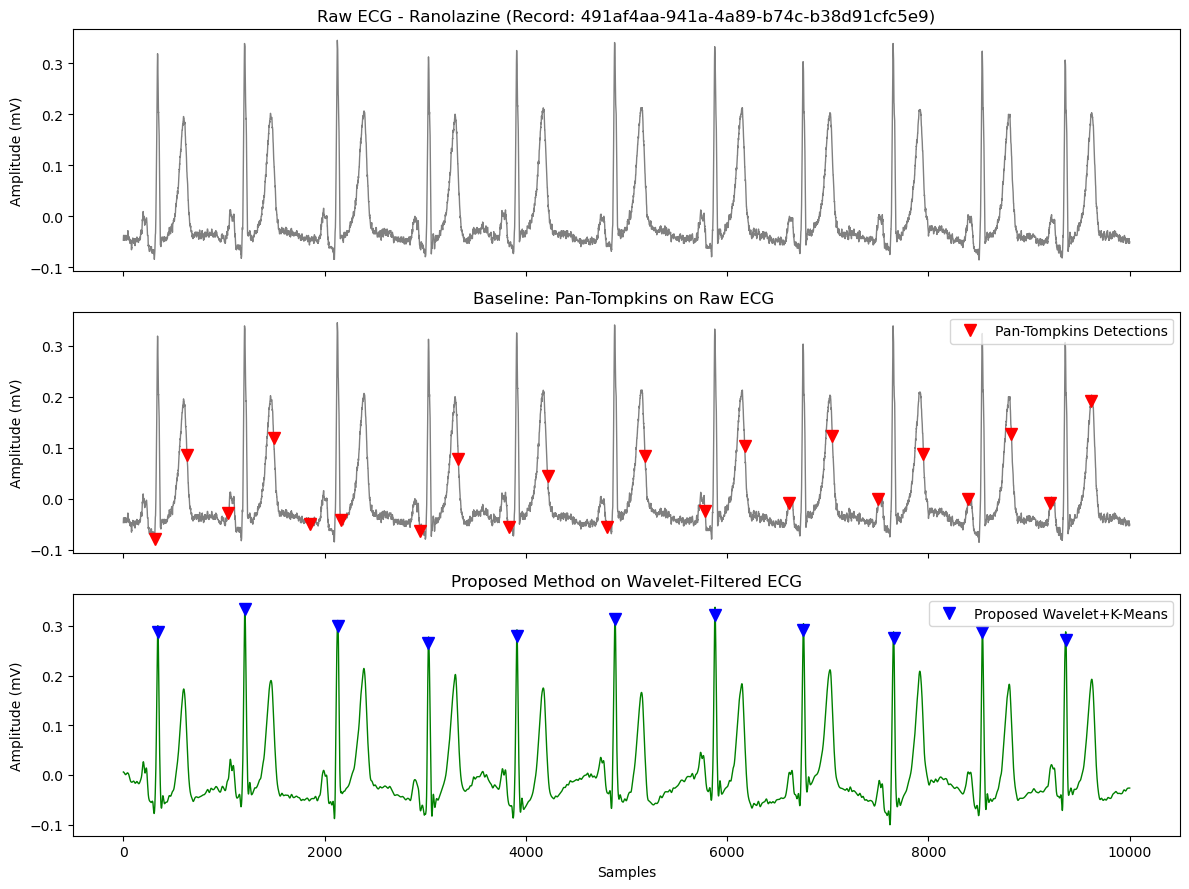

In [72]:
import matplotlib.pyplot as plt
import neurokit2 as nk
import wfdb

# 1. Grab the FIRST record from your subset (Ranolazine)
row = stratified_df.iloc[0]
subject_id = str(int(row["RANDID"]))
record_id = row["EGREFID"]
drug = row["EXTRT"]
pn_dir = f"ecgrdvq/1.0.0/raw/{subject_id}/"

# 2. Load the signal
record = wfdb.rdrecord(record_id, pn_dir=pn_dir)
ecg_sig = record.p_signal[:, 0].astype(float)
fs = float(record.fs)

# 3. Run both algorithms
clean_sig, proposed_peaks = detector.detect(ecg_sig)
_, info = nk.ecg_peaks(ecg_sig, sampling_rate=fs, method="pantompkins1985")
pt_peaks = info["ECG_R_Peaks"]

# 4. Limit to the first 10 seconds (10,000 samples)
limit = 10000
ecg_sig_sub = ecg_sig[:limit]
clean_sig_sub = clean_sig[:limit] 
prop_sub = proposed_peaks[proposed_peaks < limit]
pt_sub = pt_peaks[pt_peaks < limit]

# 5. Generate the Comparison Plot
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# Top Subplot: Raw ECG
axes[0].plot(ecg_sig_sub, 'gray', linewidth=1)
axes[0].set_title(f"Raw ECG - {drug} (Record: {record_id})")
axes[0].set_ylabel("Amplitude (mV)")

# Middle Subplot: Pan-Tompkins Failure
axes[1].plot(ecg_sig_sub, 'gray', linewidth=1)
axes[1].plot(pt_sub, ecg_sig_sub[pt_sub], 'rv', markersize=8, label="Pan-Tompkins Detections")
axes[1].set_title("Baseline: Pan-Tompkins on Raw ECG ")
axes[1].set_ylabel("Amplitude (mV)")
axes[1].legend(loc="upper right")

# Bottom Subplot: Proposed Success
axes[2].plot(clean_sig_sub, 'green', linewidth=1) 
axes[2].plot(prop_sub, clean_sig_sub[prop_sub], 'bv', markersize=8, label="Proposed Wavelet+K-Means")
axes[2].set_title("Proposed Method on Wavelet-Filtered ECG")
axes[2].set_ylabel("Amplitude (mV)")
axes[2].set_xlabel("Samples")
axes[2].legend(loc="upper right")

plt.tight_layout()
plt.show()